# Brain Clock — GBR-based Age Prediction on Artificial Dataset

Demonstrates a brain-clock pipeline using a **Gradient Boosting Regressor (GBR)**:
1. Generate synthetic regression dataset
2. Fit GBR with k-fold cross-validation + bias correction (GAP correction via GLM)
3. Compute feature importance and directional effects (OLS per feature)
4. Visualise results


## 1. Imports and helper functions

In [2]:
from sklearn.ensemble import GradientBoostingRegressor
from statsmodels.api import GLM, families
from sklearn import metrics
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import MinMaxScaler

import statsmodels.api as sm
import time, scipy, math, warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr


# ── Statistical helpers ───────────────────────────────────────

def coef_se(X_, y_, y_p):
    """OLS coefficient standard errors."""
    n  = X_.shape[0]
    X1 = np.hstack((np.ones((n, 1)), np.array(X_)))
    se_matrix = scipy.linalg.sqrtm(
        metrics.mean_squared_error(y_, y_p) * np.linalg.inv(X1.T @ X1)
    )
    return np.diagonal(se_matrix)


def coef_tval(coef_array_mean_, X_, y_, y_p):
    """t-values for OLS coefficients."""
    se = coef_se(X_, y_, y_p)
    a  = np.array(coef_array_mean_[0][0] / se[0])
    b  = np.array(coef_array_mean_[1:].flatten() / se[1:])
    return np.append(a, b)


def coef_pval(coef_array_mean_, X_, y_, y_p):
    """Two-sided p-values from t-distribution."""
    n = X_.shape[0]
    t = coef_tval(coef_array_mean_, X_, y_, y_p)
    return 2 * (1 - scipy.stats.t.cdf(np.abs(t), n - 1))


def mean_directional_accuracy(y_true, y_pred):
    """Mean signed direction error."""
    return float(np.mean(np.sign(np.array(y_pred) - np.array(y_true))))


def mean_absolute_error(y_true, y_pred):
    """Mean absolute error (custom — includes sign info via mean)."""
    # BUG FIXED: original was missing np.abs() → computed mean signed error
    return float(np.mean(np.abs(np.array(y_pred) - np.array(y_true))))


# ── Main regression function ──────────────────────────────────

def Regression_GBR(X, y, min_, max_, n_splits, params_b=-1, shaps_comp=False):
    """
    GBR with k-fold CV + GAP bias correction.

    Parameters
    ----------
    X         : pd.DataFrame of features
    y         : pd.Series of target
    min_, max_: range of random seeds (one run per seed)
    n_splits  : number of CV folds
    params_b  : dict of GBR hyperparameters, or -1 for defaults
    shaps_comp: if True, return SHAP explainer as 4th element

    Returns
    -------
    [coef_df, r_squared, results_labels_df] or [..., explainer]
    """
    scaler       = MinMaxScaler((0.05, 0.95))
    X_scaled     = pd.DataFrame(
        scaler.fit_transform(X), columns=X.columns, index=X.index
    )

    for i in range(min_, max_):
        y_labels, y_predicts = [], []
        r_squared_l, mse_l, rmse_l = [], [], []

        results_labels_df = pd.DataFrame(
            columns=['y_labels', 'y_pred', 'GAP', 'GAP_corrected', 'ID']
        )

        kf        = KFold(n_splits=n_splits, shuffle=True, random_state=i)
        lista_vars = list(X_scaled.columns)
        coef_array = np.zeros([len(lista_vars) + 1, n_splits])
        iter_      = 0

        for train_idx, test_idx in kf.split(X_scaled):
            warnings.filterwarnings("ignore")

            X_train = X_scaled.iloc[train_idx]
            X_test  = X_scaled.iloc[test_idx]
            y_train = y.iloc[train_idx]
            y_test  = y.iloc[test_idx]

            model = (GradientBoostingRegressor(random_state=42)
                     if params_b == -1
                     else GradientBoostingRegressor(random_state=42, **params_b))

            # BUG FIXED: original called model.fit(X, y) AFTER fit(X_train, y_train)
            # which overwrote the fold model with a full-data model.
            # Now we only fit once per fold on training data.
            model.fit(X_train, y_train)

            coef_array[0, iter_]  = np.nan
            coef_array[1:, iter_] = model.feature_importances_

            predicted_values = model.predict(X_test)

            y_labels.extend(list(y_test))
            y_predicts.extend(list(predicted_values))

            gap_test  = predicted_values - y_test.values
            gap_train = model.predict(X_train) - y_train.values

            # GAP bias correction via GLM on training set
            model_gap    = GLM(gap_train, y_train.values,
                               family=families.Gaussian()).fit()
            corrected_gap = gap_test + model_gap.predict(y_test.values)

            r_squared_l.append(r2_score(y_train, model.predict(X_train)))
            mse_l.append(mean_squared_error(y_test, predicted_values))
            rmse_l.append(math.sqrt(mean_squared_error(y_test, predicted_values)))

            temp_df = pd.DataFrame(
                np.column_stack((y_test.values, predicted_values,
                                 gap_test, corrected_gap)),
                columns=['y_labels', 'y_pred', 'GAP', 'GAP_corrected']
            )
            temp_df['ID'] = X_test.index
            results_labels_df = pd.concat(
                [results_labels_df, temp_df], ignore_index=True
            )
            iter_ += 1

        n, p  = len(y_predicts), X_scaled.shape[1]
        k     = n_splits

        r_squared     = r2_score(y_labels, y_predicts)
        r_squared_adj = 1 - (1 - r_squared) * (n - 1) / (n - k - 1)
        mse           = np.round(mean_squared_error(y_labels, y_predicts), 6)
        rmse          = np.round(math.sqrt(mse), 6)
        mde           = mean_directional_accuracy(y_labels, y_predicts)
        mae           = mean_absolute_error(y_labels, y_predicts)
        F             = (r_squared / p) / ((1 - r_squared) / (n - p - 1))
        p_value       = np.round(scipy.stats.f.sf(F, p, n - p - 1), 15)
        F2            = r_squared / (1 - r_squared)

        coef_array_mean = coef_array.mean(axis=1, keepdims=True)
        coef_array_std  = coef_array.std(axis=1, keepdims=True)

        coef_df = pd.DataFrame(
            index=['_intercept'] + lista_vars,
            columns=['Estimate mean', 'Estimate std', 't value', 'p value']
        )
        coef_df['Estimate mean'] = coef_array_mean
        coef_df['Estimate std']  = coef_array_std
        coef_df['t value']       = coef_tval(coef_array_mean, X_scaled,
                                              y_labels, y_predicts)
        coef_df['p value']       = coef_pval(coef_array_mean, X_scaled,
                                              y_labels, y_predicts)

        for col, val in [
            ('R2', r_squared), ('R2 adj', r_squared_adj),
            ('R2 [+-]', np.std(r_squared_l)), ('F2', F2),
            ('mse', mse), ('mse [+-]', np.std(mse_l)),
            ('rmse', rmse), ('rmse [+-]', np.std(rmse_l)),
            ('outcome var', np.var(y)), ('F', F), ('F-p_value', p_value),
            ('MDE', mde), ('MAE', mae),
        ]:
            coef_df.loc['_intercept', col] = val

    results_labels_df['y_pred_corrected'] = (
        results_labels_df['y_labels'] + results_labels_df['GAP_corrected']
    )
    results_labels_df = results_labels_df[
        ['ID', 'y_labels', 'y_pred', 'GAP', 'GAP_corrected', 'y_pred_corrected']
    ]

    if shaps_comp:
        import shap
        final_model = (GradientBoostingRegressor(random_state=42)
                       if params_b == -1
                       else GradientBoostingRegressor(random_state=42, **params_b))
        final_model.fit(X_scaled, y)
        explainer = shap.Explainer(final_model, X_scaled)
        return [coef_df, r_squared, results_labels_df, explainer]

    return [coef_df, r_squared, results_labels_df]


# ── Direction helper ──────────────────────────────────────────

def compute_directions(X_ols_all, y_ols):
    """
    Fit a univariate OLS per feature (MinMax-scaled) and extract
    the coefficient and Bonferroni-corrected p-value.
    """
    df_directions = pd.DataFrame()
    n_features    = len(X_ols_all.columns)

    for col in X_ols_all.columns:
        X_col = X_ols_all[[col]]
        scaler = MinMaxScaler((0.05, 0.95))
        X_sc   = pd.DataFrame(
            scaler.fit_transform(X_col), columns=[col], index=X_col.index
        )
        X_sc['intercept'] = 1
        model  = sm.OLS(y_ols, X_sc).fit()

        coef  = model.params[col]
        pval  = model.pvalues[col] * n_features   # Bonferroni correction

        df_directions.loc[col, 'coef'] = coef
        df_directions.loc[col, 'p']    = min(pval, 1.0)

    return df_directions.reset_index()


def plot_coef(coef_df_all, results_labels_df_all):
    """Bar plot of GBR feature importances + model metrics in title."""
    df = (coef_df_all.iloc[1:, :2]
          .sort_values('Estimate mean', ascending=False))

    sns.barplot(x='Estimate mean', y=df.index, data=df, orient='h')
    plt.xlabel('Feature importance (GBR)')
    plt.ylabel('Features')
    plt.xlim([0, 0.55])

    r2   = np.round(coef_df_all.loc['_intercept', 'R2'], 2)
    rmse = np.round(coef_df_all.loc['_intercept', 'rmse'], 2)
    plt.title(f'R²={r2}  RMSE={rmse}')

print("Imports and helpers loaded.")


Imports and helpers loaded.


## 2. Generate synthetic dataset

In [3]:
from sklearn.datasets import make_regression

X_raw, y_raw = make_regression(
    n_samples=100, n_features=5, noise=0.1, random_state=42
)

df_continuous = pd.DataFrame(
    X_raw, columns=[f'predictor_{i+1}' for i in range(X_raw.shape[1])]
)
df_continuous['continuous_target'] = y_raw

# Add non-linear transforms to two predictors
df_continuous['predictor_1'] = (
    10 - df_continuous['predictor_1'] / df_continuous['predictor_1'].max()
)
df_continuous['predictor_3'] = (
    10 - df_continuous['predictor_3'] / df_continuous['predictor_3'].max()
)

print(df_continuous.describe().round(2))


       predictor_1  predictor_2  predictor_3  predictor_4  predictor_5  \
count       100.00       100.00       100.00       100.00       100.00   
mean         10.01         0.13        10.02         0.08        -0.09   
std           0.28         0.96         0.39         0.98         0.98   
min           9.00        -1.91         9.00        -2.30        -3.24   
25%           9.83        -0.54         9.77        -0.68        -0.70   
50%          10.04         0.15        10.00         0.07        -0.02   
75%          10.20         0.67        10.32         0.83         0.53   
max          10.68         3.08        10.84         1.89         2.12   

       continuous_target  
count             100.00  
mean                8.84  
std               140.61  
min              -341.18  
25%               -83.64  
50%                 4.86  
75%               106.95  
max               399.56  


## 3. Fit GBR brain clock

In [4]:
X_ = df_continuous.drop(columns=['continuous_target'])
y  = df_continuous['continuous_target']

coef_df_, r_squared_, results_labels_df_ = Regression_GBR(
    X_, y, min_=1, max_=2, n_splits=10, params_b=-1, shaps_comp=False
)

print(coef_df_.to_string())


             Estimate mean  Estimate std   t value   p value        R2    R2 adj   R2 [+-]        F2          mse     mse [+-]       rmse  rmse [+-]   outcome var          F  F-p_value   MDE        MAE
_intercept             NaN           NaN       NaN       NaN  0.825253  0.805618  0.000163  4.722549  3420.454824  1795.136496  58.484655  14.432473  19573.721541  88.783928        0.0  0.02  43.283325
predictor_1       0.185680      0.017558  0.005130  0.995917       NaN       NaN       NaN       NaN          NaN          NaN        NaN        NaN           NaN        NaN        NaN   NaN        NaN
predictor_2       0.469445      0.022016  0.014218  0.988685       NaN       NaN       NaN       NaN          NaN          NaN        NaN        NaN           NaN        NaN        NaN   NaN        NaN
predictor_3       0.110324      0.010870  0.003709  0.997048       NaN       NaN       NaN       NaN          NaN          NaN        NaN        NaN           NaN        NaN        NaN   NaN  

## 4. Feature importances and directional effects

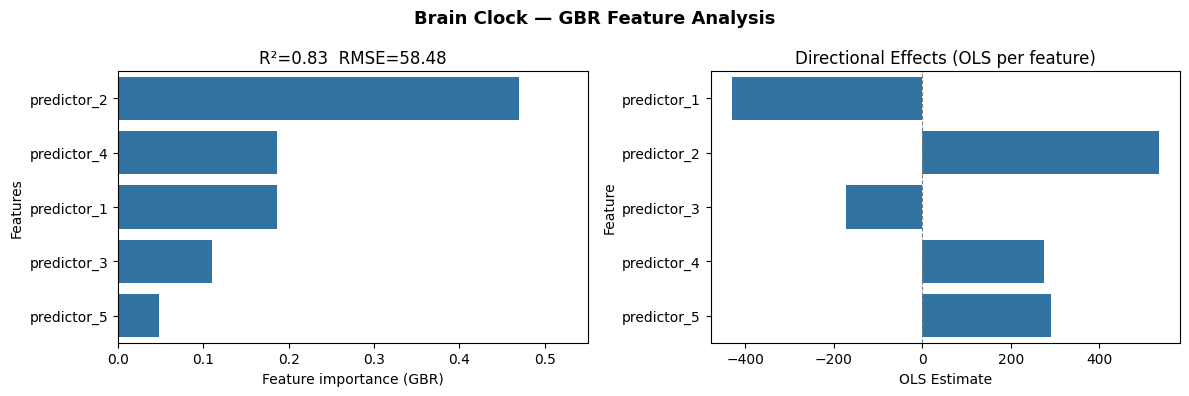

In [5]:
dirs = compute_directions(X_, y)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Brain Clock — GBR Feature Analysis', fontsize=13, fontweight='bold')

plt.sca(axes[0])
plot_coef(coef_df_, results_labels_df_)

# BUG FIXED: original called sns.barplot twice (second overwrote first)
axes[1].set_title('Directional Effects (OLS per feature)')
sns.barplot(data=dirs, x='coef', y='index', orient='h', ax=axes[1])
axes[1].axvline(0, color='gray', lw=0.8, ls='--')
axes[1].set_xlabel('OLS Estimate')
axes[1].set_ylabel('Feature')

plt.tight_layout()
plt.show()


## 5. Predicted vs Actual + GAP distribution

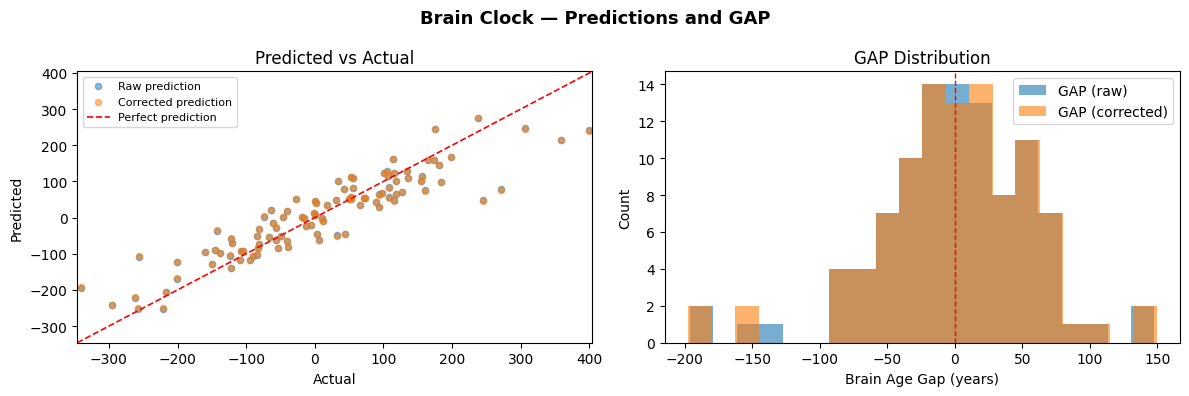

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Brain Clock — Predictions and GAP', fontsize=13, fontweight='bold')

ax = axes[0]
ax.scatter(results_labels_df_['y_labels'], results_labels_df_['y_pred'],
           alpha=0.5, s=20, label='Raw prediction')
ax.scatter(results_labels_df_['y_labels'], results_labels_df_['y_pred_corrected'],
           alpha=0.5, s=20, label='Corrected prediction')
lims = [results_labels_df_['y_labels'].min()-5, results_labels_df_['y_labels'].max()+5]
ax.plot(lims, lims, 'r--', lw=1.2, label='Perfect prediction')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
ax.set_title('Predicted vs Actual'); ax.legend(fontsize=8)

ax = axes[1]
ax.hist(results_labels_df_['GAP'], bins=20, alpha=0.6, label='GAP (raw)')
ax.hist(results_labels_df_['GAP_corrected'], bins=20, alpha=0.6, label='GAP (corrected)')
ax.axvline(0, color='red', ls='--', lw=1)
ax.set_xlabel('Brain Age Gap (years)'); ax.set_ylabel('Count')
ax.set_title('GAP Distribution'); ax.legend()

plt.tight_layout()
plt.show()
